## 🧑‍🏫 VERSIÓN SOLUCIÓN (docente)

# Desafío: Efecto de los Hiperparámetros en el Entrenamiento y la Generalización

En el laboratorio de generalización entrenamos una red feed-forward sobre CIFAR-10 y comparamos la pérdida y el acierto (accuracy) en el conjunto de entrenamiento (train) contra el conjunto de prueba (test/validación).

En este desafío te toca a ti: vas a **completar el código** que permite entrenar la misma red cambiando distintos hiperparámetros, y vas a **responder preguntas de reflexión** a partir de los gráficos que tú mismo generes.

Vamos a estudiar cuatro hiperparámetros:

1. **Tasa de aprendizaje (learning rate)**
2. **Tamaño de batch (batch size)**
3. **Capacidad de la red (cantidad de neuronas)**
4. **Regularización (Dropout)**

**Instrucciones:**
- Completa cada celda marcada con `# TODO`. Hay pistas en los comentarios.
- Después de cada experimento hay una celda de markdown marcada con ✍️ donde debes escribir tu respuesta, basada en **tus propios gráficos** (no van a ser exactamente iguales entre compañeros, ¡y eso está bien!).
- Tiempo estimado: **30 a 45 minutos**.

In [ ]:
# Importamos librerías necesarias

from tensorflow import keras
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt

In [ ]:
# Cargamos datos de entrenamiento y prueba de CIFAR10

(imgs_train, labs_train), (imgs_test, labs_test) = keras.datasets.cifar10.load_data()
print(imgs_train.shape)
print(imgs_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


### Reducimos el tamaño del dataset

Vamos a entrenar la red muchas veces (una por cada configuración de hiperparámetros), así que usamos solo una **muestra al azar** del dataset completo en vez de las 50.000/10.000 imágenes originales. Esto hace que cada entrenamiento sea mucho más rápido.

Como efecto secundario, con **menos datos de entrenamiento** es más fácil que la red memorice el conjunto de entrenamiento, así que el overfitting se va a notar incluso más claro en los experimentos de capacidad y regularización.

In [ ]:
N_TRAIN = 6000  # cantidad de imágenes de entrenamiento a usar (de las 50.000 originales)
N_TEST = 1500   # cantidad de imágenes de validación a usar (de las 10.000 originales)

np.random.seed(42)
idx_train = np.random.choice(len(imgs_train), N_TRAIN, replace=False)
idx_test = np.random.choice(len(imgs_test), N_TEST, replace=False)

imgs_train = imgs_train[idx_train]
labs_train = labs_train[idx_train]
imgs_test = imgs_test[idx_test]
labs_test = labs_test[idx_test]

print(imgs_train.shape)
print(imgs_test.shape)

(6000, 32, 32, 3)
(1500, 32, 32, 3)


In [ ]:
nombres = ['avión', 'auto', 'pájaro', 'gato', 'venado', 'perro', 'rana', 'caballo', 'barco', 'camión']

In [ ]:
# Tranformamos los datos para el entrenamiento,
# Necesitamos transformar tanto el train como el test

X_train = imgs_train.reshape(len(imgs_train), 32*32*3)
X_test = imgs_test.reshape(len(imgs_test), 32*32*3)
X_train = X_train / 255
X_test = X_test / 255
print('X', X_train.shape, X_test.shape)

Y_train = keras.utils.to_categorical(labs_train, 10)
Y_test = keras.utils.to_categorical(labs_test, 10)
print('Y', Y_train.shape, Y_test.shape)

X (6000, 3072) (1500, 3072)
Y (6000, 10) (1500, 10)


In [ ]:
# cantidad de ejemplos (train/test), neuronas de entrada y neuronas de salida

M_train = X_train.shape[0]
M_test = X_test.shape[0]

N = X_train.shape[1]
C = Y_train.shape[1]

print(N, C, M_train, M_test)

3072 10 6000 1500


## Parte 1: Completa la función `construir_y_entrenar`

Esta función debe construir una red feed-forward y entrenarla sobre CIFAR-10, recibiendo todos los hiperparámetros como parámetros:

- `capas_ocultas`: lista con la cantidad de neuronas de cada capa escondida (ej. `[512, 256, 256]`)
- `tasa_aprendizaje`: learning rate del optimizador SGD
- `batch_size`: tamaño del batch
- `epochs`: cantidad de épocas de entrenamiento
- `dropout`: probabilidad de Dropout después de cada capa escondida (0 = sin regularización)
- `seed`: semilla para que los resultados sean reproducibles

La arquitectura base ya está definida: capas `Dense` con activación `relu` y salida `Softmax`; el optimizador es siempre `SGD` y la función de error es `categorical_crossentropy`, igual que en el laboratorio anterior.

In [ ]:
def construir_y_entrenar(capas_ocultas=[512, 256, 256], tasa_aprendizaje=0.01,
                          batch_size=128, epochs=20, dropout=0.0, seed=30, verbose=0):
    # Construye una red feed-forward y la entrena sobre CIFAR-10.
    # Devuelve el objeto History de Keras con la pérdida y el acierto
    # por época, tanto en train como en validación (test).
    np.random.seed(seed)
    tf.random.set_seed(seed)

    red = keras.Sequential()
    red.add(keras.layers.Dense(capas_ocultas[0], input_dim=N, activation='relu'))
    if dropout > 0:
        red.add(keras.layers.Dropout(dropout))

    for h in capas_ocultas[1:]:
        red.add(keras.layers.Dense(h, activation='relu'))
        if dropout > 0:
            red.add(keras.layers.Dropout(dropout))

    red.add(keras.layers.Dense(C, activation='softmax'))

    optimizador = keras.optimizers.SGD(learning_rate=tasa_aprendizaje)

    red.compile(
        loss='categorical_crossentropy',
        optimizer=optimizador,
        metrics=['accuracy']
    )

    hist = red.fit(X_train, Y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(X_test, Y_test),
                    verbose=verbose)

    return hist

## Parte 2: Completa la función `graficar_comparacion`

Esta función recibe un diccionario `{etiqueta: history}` y debe dibujar **dos gráficos lado a lado**:

- A la izquierda, la **pérdida** (loss) de train (línea continua) y de validación (línea punteada) para cada experimento.
- A la derecha, el **acierto** (accuracy) de train y de validación para cada experimento.

Así podremos comparar de un vistazo varias configuraciones de hiperparámetros en el mismo gráfico.

In [ ]:
def graficar_comparacion(historias, titulo):
    # historias: diccionario {etiqueta: history de Keras}
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(14, 5))

    colores = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for i, (etiqueta, hist) in enumerate(historias.items()):
        color = colores[i % len(colores)]
        ax_loss.plot(hist.history['loss'], color=color, linestyle='-', label=f'{etiqueta} (train)')
        ax_loss.plot(hist.history['val_loss'], color=color, linestyle='--', label=f'{etiqueta} (val)')

        ax_acc.plot(hist.history['accuracy'], color=color, linestyle='-', label=f'{etiqueta} (train)')
        ax_acc.plot(hist.history['val_accuracy'], color=color, linestyle='--', label=f'{etiqueta} (val)')

    ax_loss.set_title(f'Pérdida — {titulo}')
    ax_loss.set_xlabel('Época')
    ax_loss.set_ylabel('Pérdida (crossentropy)')
    ax_loss.legend(fontsize=8)

    ax_acc.set_title(f'Acierto — {titulo}')
    ax_acc.set_xlabel('Época')
    ax_acc.set_ylabel('% Acierto')
    ax_acc.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

## Experimento 1: Tasa de aprendizaje (learning rate)

Vamos a entrenar la **misma arquitectura** (`[512, 256, 256]`), el mismo batch size (128) y la misma cantidad de épocas, cambiando solo la tasa de aprendizaje del descenso del gradiente.

Entrenando con tasa de aprendizaje = 0.001 ...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando con tasa de aprendizaje = 0.01 ...
Entrenando con tasa de aprendizaje = 0.5 ...


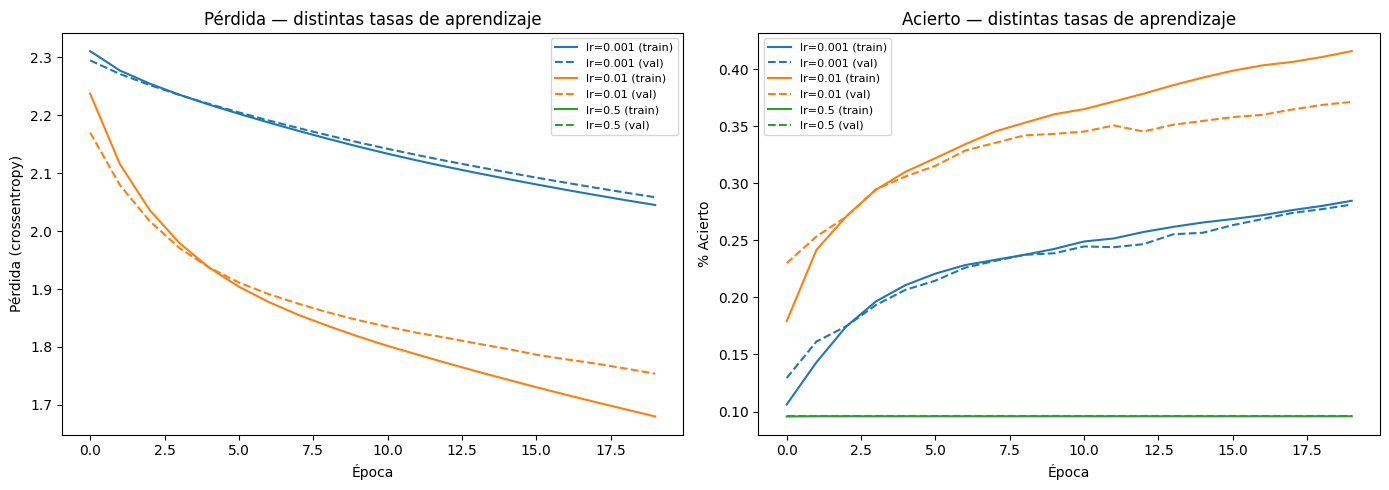

In [ ]:
historias_lr = {}
for lr in [0.001, 0.01, 0.5]:
    print(f'Entrenando con tasa de aprendizaje = {lr} ...')
    historias_lr[f'lr={lr}'] = construir_y_entrenar(tasa_aprendizaje=lr, epochs=20)

graficar_comparacion(historias_lr, 'distintas tasas de aprendizaje')

**✍️ Tu respuesta:** Observando tus gráficos, ¿qué le pasó a la pérdida y al acierto con la tasa de aprendizaje más baja? ¿Y con la más alta? ¿Cuál de las tres tasas te parece la más adecuada para este problema y por qué?

> *(escribe tu respuesta aquí)*

## Experimento 2: Tamaño de batch (batch size)

Ahora fijamos la tasa de aprendizaje (0.01) y la arquitectura, y cambiamos el tamaño del batch. Recuerda que tenemos `N_TRAIN` = 6.000 ejemplos de entrenamiento, así que un batch tiene que ser menor a esa cantidad.

Entrenando con batch_size = 16 ...
Entrenando con batch_size = 128 ...
Entrenando con batch_size = 3000 ...


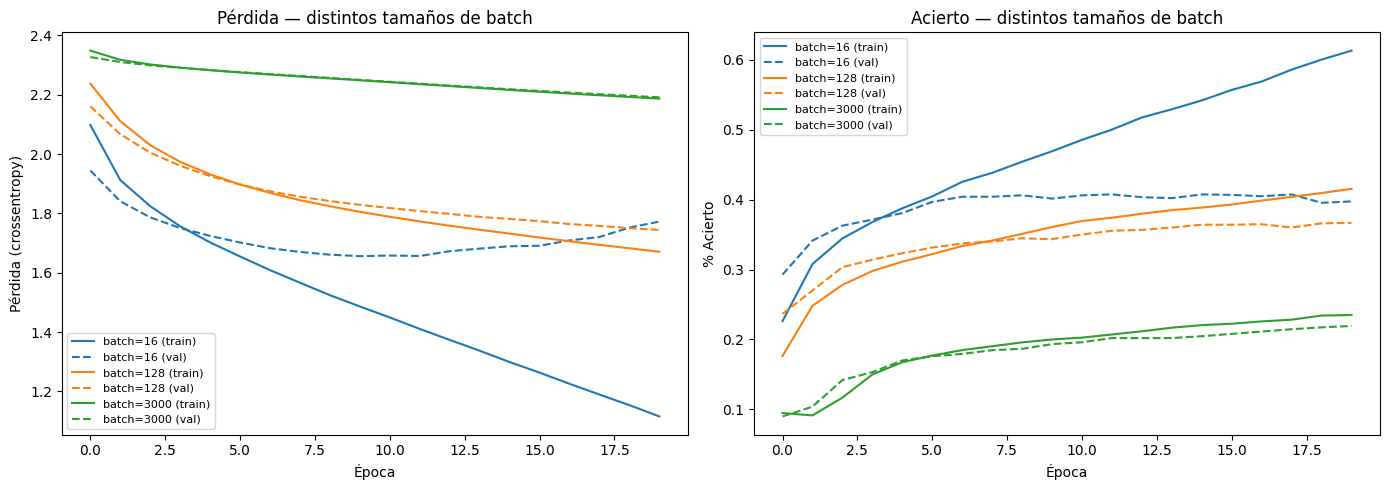

In [ ]:
historias_batch = {}
for bs in [16, 128, 3000]:
    print(f'Entrenando con batch_size = {bs} ...')
    historias_batch[f'batch={bs}'] = construir_y_entrenar(tasa_aprendizaje=0.01, batch_size=bs, epochs=20)

graficar_comparacion(historias_batch, 'distintos tamaños de batch')

**✍️ Tu respuesta:** ¿Qué diferencia notaste en la cantidad de "vaivén" o ruido de las curvas entre el batch más chico y el más grande? Según lo que vimos en clase sobre descenso del gradiente y SGD, ¿por qué crees que pasa esto?

> *(escribe tu respuesta aquí)*

## Experimento 3: Capacidad de la red

Comparemos tres arquitecturas con distinta cantidad de neuronas: una red **pequeña**, la red **original** del notebook base, y una red **mucho más grande**. La tasa de aprendizaje, el batch size y la cantidad de épocas se mantienen fijos.

Entrenando red pequeña [32] ...
Entrenando red original [512,256,256] ...
Entrenando red grande [1024,1024,512] ...


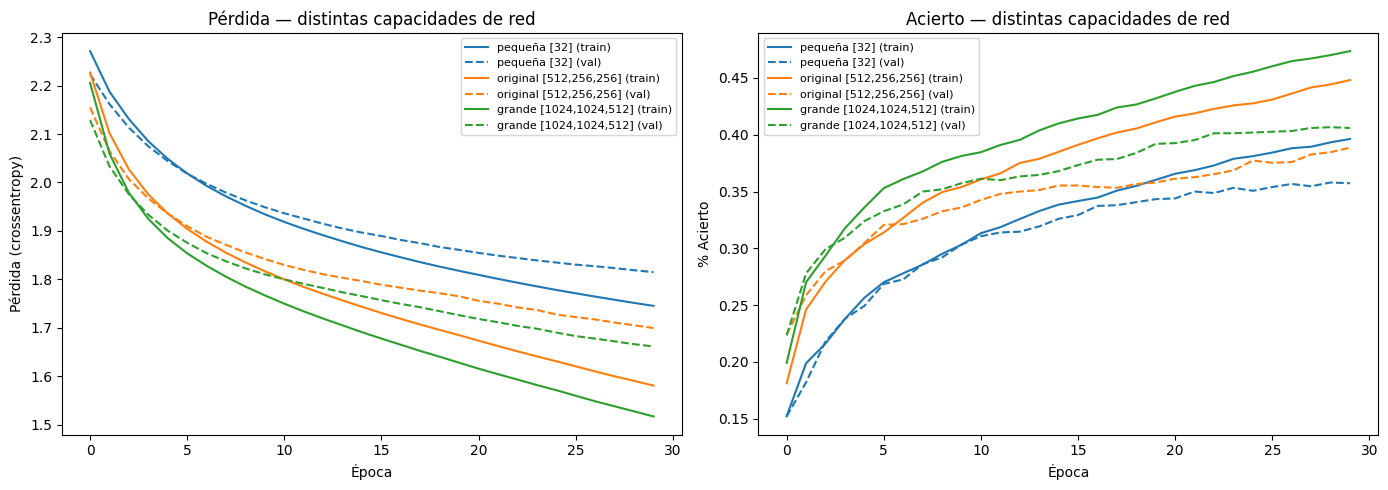

In [ ]:
historias_capacidad = {}
arquitecturas = {
    'pequeña [32]': [32],
    'original [512,256,256]': [512, 256, 256],
    'grande [1024,1024,512]': [1024, 1024, 512],
}

for etiqueta, capas in arquitecturas.items():
    print(f'Entrenando red {etiqueta} ...')
    historias_capacidad[etiqueta] = construir_y_entrenar(capas_ocultas=capas, tasa_aprendizaje=0.01, epochs=30)

graficar_comparacion(historias_capacidad, 'distintas capacidades de red')

**✍️ Tu respuesta:** ¿Cuál de las tres redes logró el menor error de entrenamiento? ¿Es también la que logró el menor error de validación? Si notaste una diferencia entre ambas preguntas, ¿cómo se llama ese fenómeno?

> *(escribe tu respuesta aquí)*

## Experimento 4: Regularización con Dropout

Por último, toma la red **grande** del experimento anterior (la más propensa a hacer overfitting) y compárala entrenada **sin** y **con** Dropout, una técnica de regularización que "apaga" al azar un porcentaje de las neuronas en cada paso de entrenamiento para evitar que la red dependa demasiado de combinaciones específicas de neuronas.

Entrenando red grande sin Dropout ...
Entrenando red grande con Dropout = 0.4 ...


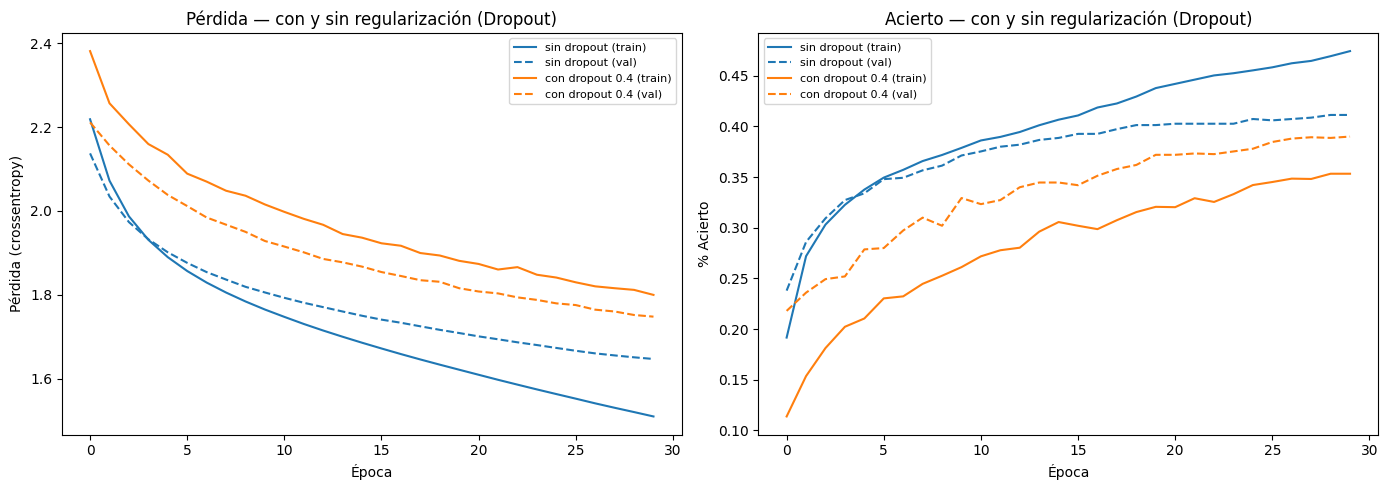

In [ ]:
historias_dropout = {}

print('Entrenando red grande sin Dropout ...')
historias_dropout['sin dropout'] = construir_y_entrenar(
    capas_ocultas=[1024, 1024, 512], tasa_aprendizaje=0.01, epochs=30, dropout=0.0)

print('Entrenando red grande con Dropout = 0.4 ...')
historias_dropout['con dropout 0.4'] = construir_y_entrenar(
    capas_ocultas=[1024, 1024, 512], tasa_aprendizaje=0.01, epochs=30, dropout=0.4)

graficar_comparacion(historias_dropout, 'con y sin regularización (Dropout)')

**✍️ Tu respuesta:** Comparando el error de entrenamiento y el de validación entre la red con y sin Dropout, ¿cuál generaliza mejor? ¿Es también la que tiene el menor error de entrenamiento? ¿Por qué crees que pasa esto?

> *(escribe tu respuesta aquí)*

## Conclusión

Completa la siguiente tabla con lo que observaste en tus propios experimentos (una o dos frases por celda):

| Hiperparámetro | Efecto principal que observaste |
|---|---|
| **Tasa de aprendizaje** | *(tu respuesta)* |
| **Tamaño de batch** | *(tu respuesta)* |
| **Capacidad de la red** | *(tu respuesta)* |
| **Regularización (Dropout)** | *(tu respuesta)* |

## 🎁 Bonus (opcional)

Antes de ejecutar nada, **predice** qué crees que va a pasar si combinas: una red **grande** (`[1024, 1024, 512]`), una tasa de aprendizaje **alta** (`0.5`) y un batch **chico** (`16`), todo al mismo tiempo. Escribe tu predicción y luego compruébala entrenando esa configuración con `construir_y_entrenar` y graficando el resultado junto a la configuración original (`[512,256,256]`, `lr=0.01`, `batch=128`) para comparar.

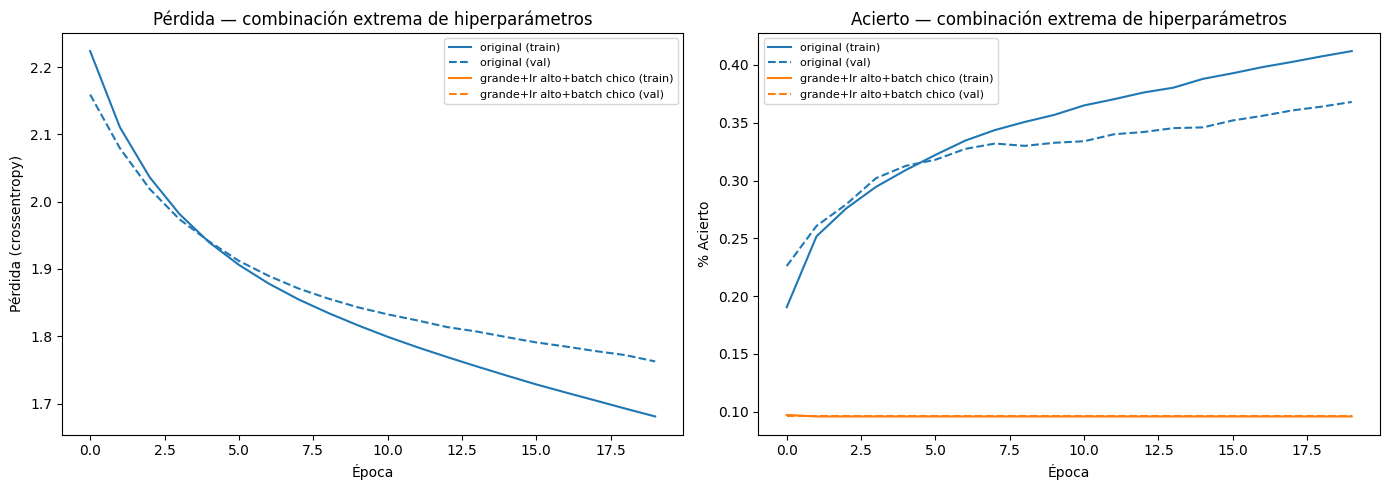

In [13]:
# Predicción (ejemplo de respuesta docente): al combinar alta capacidad, tasa de
# aprendizaje alta y batch chico, se espera un entrenamiento muy inestable: la tasa
# alta puede hacer que la pérdida oscile o diverja, y como la red es grande, si logra
# converger es probable que sobreajuste rápido dado el batch chico (muchas actualizaciones).

historias_bonus = {}
historias_bonus['original'] = construir_y_entrenar(
    capas_ocultas=[512, 256, 256], tasa_aprendizaje=0.01, batch_size=128, epochs=20)
historias_bonus['grande+lr alto+batch chico'] = construir_y_entrenar(
    capas_ocultas=[1024, 1024, 512], tasa_aprendizaje=0.5, batch_size=16, epochs=20)

graficar_comparacion(historias_bonus, 'combinación extrema de hiperparámetros')